In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
hist_df=pd.read_csv("data.csv")
hist_df.head()

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


In [3]:
train_data=hist_df[hist_df["day"]>55]
train_data

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
21505,0,56,0,123.89,262.19,379.65,225.53,186.89,263.56
21506,1,56,1,123.96,262.14,380.22,226.30,187.28,263.99
21507,2,56,2,123.99,262.48,380.07,226.41,186.89,263.96
21508,3,56,3,124.27,262.94,380.15,225.78,186.90,263.93
21509,4,56,4,124.45,262.95,380.44,224.76,187.13,263.81
...,...,...,...,...,...,...,...,...,...
23455,386,60,386,121.71,261.64,362.42,208.12,193.39,256.39
23456,387,60,387,121.63,261.68,362.00,208.87,192.79,256.33
23457,388,60,388,121.78,262.01,362.27,209.52,193.42,256.81
23458,389,60,389,121.65,261.07,362.55,209.51,193.33,256.62


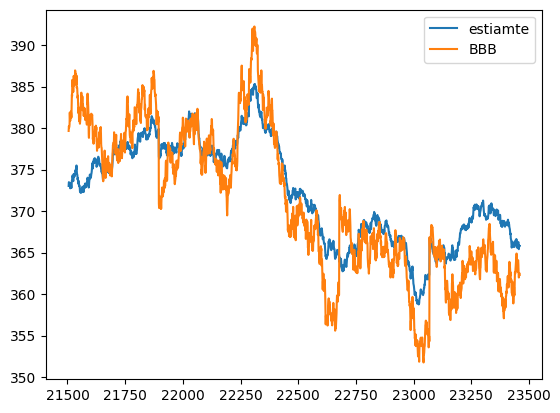

In [16]:
intercept,coef=95.46931822547003,1.05311287
sd=4.31792969543484

secutiry1="ETF"
secutiry2="BBB"

y_fit=train_data[secutiry1]*coef+intercept
plt.plot(y_fit, label="estiamte")
plt.plot(train_data[secutiry2],label=secutiry2)
#plt.plot(test_data["IND"],label=["IND"])

plt.legend()

In [18]:
train_data.index

RangeIndex(start=21505, stop=23460, step=1)

In [38]:
diff=train_data[secutiry2]-y_fit
x=np.linspace(0.5,3,15)
y=np.linspace(0.1,2,15)
all=[]

mean=-1.0595512300584884

for buy_in in x:
    for back in y:
        start_capital=1000000
        total=start_capital
        tot_ETF=0
        tot_IND=0

        profit=[1]

        for i in train_data.index:
            if(i==21505): continue

            #sell etf at high
            if(diff[i]>=mean+buy_in*sd and diff[i-1]<mean+buy_in*sd):
                amount_etf=total//2//train_data[secutiry2][i]
                amount_ind=total//2//train_data[secutiry1][i]

                tot_IND+=amount_ind
                tot_ETF-=amount_etf

                total+=amount_etf*train_data[secutiry2][i]
                total-=amount_ind*train_data[secutiry1][i]

                #print(tot_ETF,i,total)

            if(diff[i]<=mean+back*sd and diff[i-1]>mean+back*sd and tot_ETF<0):
                total-=tot_ETF*train_data[secutiry2][i]
                total+=tot_IND*train_data[secutiry1][i]
                tot_ETF=0
                tot_IND=0

                #print(tot_ETF,i,total)

            #buy etf at low
            if(-diff[i]>=mean+buy_in*sd and -diff[i-1]<mean+buy_in*sd):
                amount_etf=total//2//train_data[secutiry2][i]
                amount_ind=total//2//train_data[secutiry1][i]

                tot_IND-=amount_ind
                tot_ETF+=amount_etf

                total-=amount_etf*train_data[secutiry2][i]
                total+=amount_ind*train_data[secutiry1][i]

                #print(tot_ETF,i,total)

            #go back
            if(-diff[i]<=mean+back*sd and -diff[i-1]>mean+back*sd and tot_ETF<0):
                total+=tot_ETF*train_data[secutiry2][i]
                total-=tot_IND*train_data[secutiry1][i]
                tot_ETF=0
                tot_IND=0

                #print(tot_ETF,i,total)


            profit.append(total/start_capital)


        profit=pd.DataFrame(np.array(profit))

        Rp=total/start_capital

        Rf=(train_data["IND"][23459]/train_data["IND"][21505])
        #train_data["IND"]
        sigma=np.sqrt(profit[0].var())

        sharpe=(Rp-Rf)/sigma
        all.append((Rp,Rf,sigma,total,buy_in,back))
 



In [39]:
all.sort(reverse=True)

for i in range(5):
    print(all[i])

(np.float64(59410.76546165999), np.float64(0.983614496730971), np.float64(28728.079728039967), np.float64(59410765461.65999), np.float64(1.0357142857142856), np.float64(1.05))
(np.float64(22303.62379895001), np.float64(0.983614496730971), np.float64(10785.472482937315), np.float64(22303623798.950012), np.float64(1.0357142857142856), np.float64(0.9142857142857143))
(np.float64(12487.394857800007), np.float64(0.983614496730971), np.float64(6003.19436798926), np.float64(12487394857.800007), np.float64(1.0357142857142856), np.float64(0.7785714285714285))
(np.float64(6503.7279632499985), np.float64(0.983614496730971), np.float64(3093.0549191563223), np.float64(6503727963.249998), np.float64(1.0357142857142856), np.float64(0.6428571428571428))
(np.float64(2282.0241611899987), np.float64(0.983614496730971), np.float64(891.7830747828954), np.float64(2282024161.1899986), np.float64(0.8571428571428572), np.float64(0.7785714285714285))
